# This ist ein attempt at trying to kombinée les token data und dataframe from ein model in pytorchencoder.

# Use this to make dimensionality reduction via UMAP such that it may be used for clustering.



# WHen this ist vertig, import the optimised modellen von dem richtiges bild und use that with this method to make le best possible clustering, ja?

In [55]:
import umap.umap_ as umap
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.preprocessing import StandardScaler

This works with le latest model von encoded_2_unique.csv, which contains the scrand_sized_low_res_data modellen.

In [56]:
# Load encoded image features
#df_img = pd.read_csv("encoded_unique.csv")
df_img = pd.read_csv("encoded_2_unique.csv")

print(df_img.shape)  # (N, 91) Yes yes yes

(3193, 145)


In [57]:
def data_processor(path):
    text_list = []
    data = pd.read_csv(path).fillna("")
    
    for _, row in data.iterrows():
        text_list.append(
            f"{row['title']} {row['subtitle']} {row['country']} {row['club']}"
        )
        
    return data, text_list

# Load same dataset (IMPORTANT: same ordering as encoder!)
path = r"..\..\data\grand_scraper_folder\unique_scrandle_pictures_FULL.csv"
df_text, text_list = data_processor(path)

# Vectorize
vectorizer = CountVectorizer(max_features=7000)  # limit size (important!)
X_text = vectorizer.fit_transform(text_list)

print(X_text.shape)


(3193, 3648)


In [58]:
X_text_dense = X_text.toarray()  # convert sparse → dense
X_img = df_img.values           # numpy array

print(X_img.shape)
print(X_text_dense.shape)

(3193, 145)
(3193, 3648)


In [59]:
# Normalise both separately
scaler_img = StandardScaler() 
scaler_text = StandardScaler()

X_img_scaled = scaler_img.fit_transform(X_img)
X_text_scaled = scaler_text.fit_transform(X_text_dense)

In [60]:
# Weighting (IMPORTANT tuning knob)
alpha = 0.01   # image importance
beta  = 1.0   # text importance 

X_combined = np.hstack([
    alpha * X_img_scaled,
    beta  * X_text_scaled
]) #This is how we weight the datasets importance with respect to each other.

print(X_combined.shape)

(3193, 3793)


In [61]:
reducer = umap.UMAP(
    n_neighbors=30,
    min_dist=0.1,
    n_components=2,  # 2D visualization
    random_state=42
)

X_umap = reducer.fit_transform(X_combined)
print(X_umap.shape)  # (N, 2)

c:\Users\ulrik\anaconda3\envs\appstat25\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


(3193, 2)


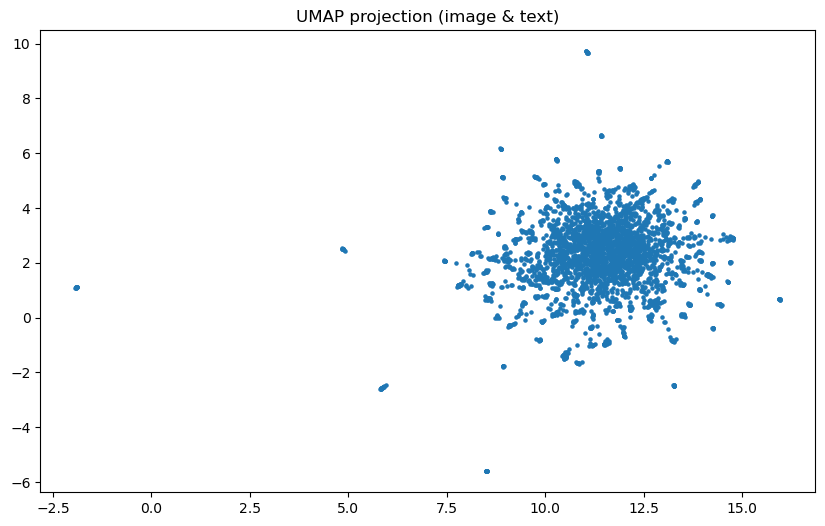

In [62]:
plt.figure(figsize=(10,6))
plt.scatter(X_umap[:,0], X_umap[:,1], s=5)
plt.title("UMAP projection (image & text)")
plt.show()


In [63]:
# Now ispection of UMAP PRojection

c:\Users\ulrik\anaconda3\envs\appstat25\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
c:\Users\ulrik\anaconda3\envs\appstat25\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
c:\Users\ulrik\anaconda3\envs\appstat25\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
c:\Users\ulrik\anaconda3\envs\appstat25\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
c:\Users\ulrik\anaconda3\envs\appstat25\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
c:\Users\ulrik\anaconda3\envs\appstat25\Lib\site-packages\umap\umap_.py:1952: Us

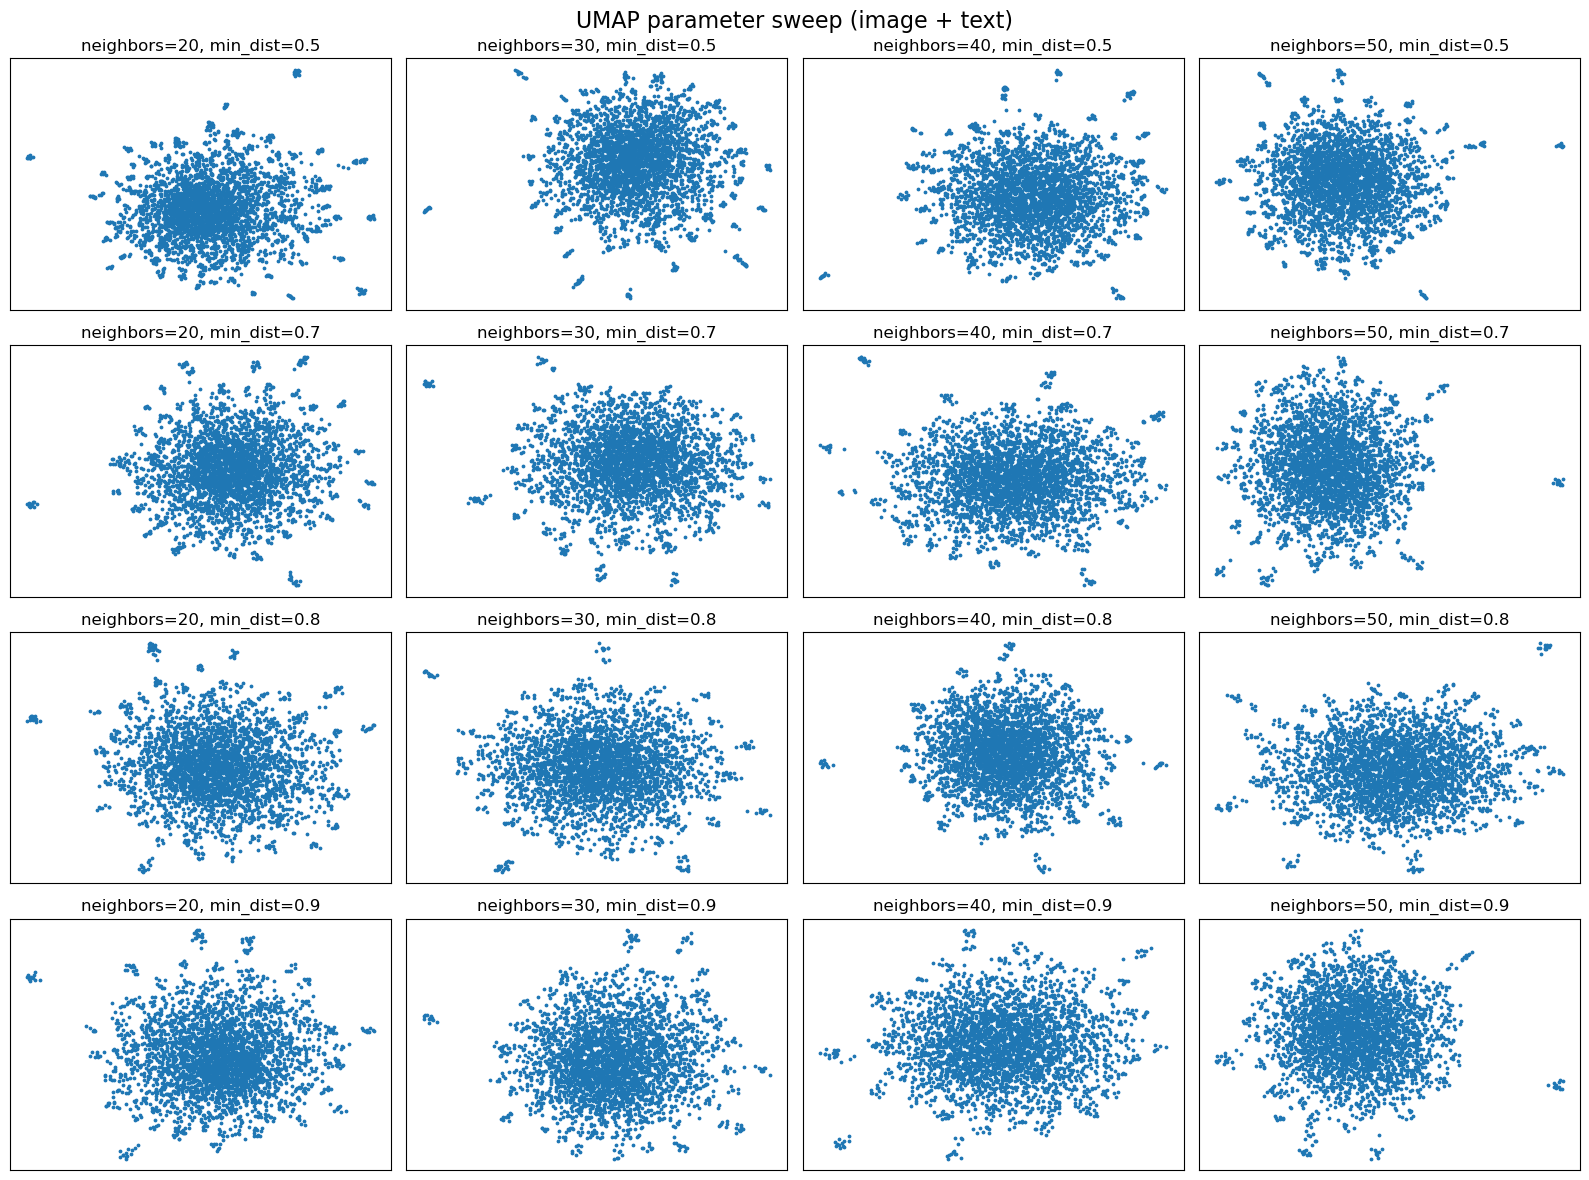

In [64]:
# Parameter ranges
min_dist_list = [0.5, 0.7, 0.8, 0.9]
n_neighbors_list = [20, 30, 40, 50]

# Create subplot grid
fig, axes = plt.subplots(len(min_dist_list), len(n_neighbors_list), figsize=(16, 12))

# Loop over all combinations
for i, min_dist in enumerate(min_dist_list):
    for j, n_neighbors in enumerate(n_neighbors_list):
        
        # Create UMAP reducer with current parameters
        reducer = umap.UMAP(
            n_neighbors=n_neighbors,
            min_dist=min_dist,
            n_components=2,
            random_state=42
        )
        
        # Fit and transform
        X_umap = reducer.fit_transform(X_combined)
        
        # Plot in the correct subplot
        ax = axes[i, j]
        ax.scatter(X_umap[:, 0], X_umap[:, 1], s=3)
        
        # Title for each subplot
        ax.set_title(f"neighbors={n_neighbors}, min_dist={min_dist}")
        
        # Remove axis ticks for clarity
        ax.set_xticks([])
        ax.set_yticks([])

# Global title
plt.suptitle("UMAP parameter sweep (image + text)", fontsize=16)

plt.tight_layout()
plt.show()

In [72]:
reducer = umap.UMAP(
    n_neighbors=30,
    min_dist=0.9,
    n_components=2,  # 2D visualization
    random_state=42
)

X_umap = reducer.fit_transform(X_combined)
print(X_umap.shape)  # (N, 2)

c:\Users\ulrik\anaconda3\envs\appstat25\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


(3193, 2)


# Und from here, ein attempt at making zhe clustering algoritmus.


In [73]:
from sklearn.cluster import KMeans, OPTICS
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score


In [79]:
def run_clustering(X, method="kmeans", n_clusters=30):
    
    if method == "kmeans":
        model = KMeans(n_clusters=n_clusters, random_state=42)
        labels = model.fit_predict(X)
    
    elif method == "gmm":
        model = GaussianMixture(n_components=n_clusters, random_state=42)
        labels = model.fit_predict(X)
    
    elif method == "optics":
        model = OPTICS(min_samples=10)
        labels = model.fit_predict(X)
    
    else:
        raise ValueError("Unknown method")
    
    return labels

In [80]:
def evaluate_clustering(X, labels):
    
    # OPTICS may produce noise (-1), remove it
    mask = labels != -1
    X_valid = X[mask]
    labels_valid = labels[mask]
    
    # If too few clusters → skip
    if len(set(labels_valid)) < 2:
        return {
            "silhouette": None,
            "davies_bouldin": None,
            "calinski_harabasz": None
        }
    
    return {
        "silhouette": silhouette_score(X_valid, labels_valid),
        "davies_bouldin": davies_bouldin_score(X_valid, labels_valid),
        "calinski_harabasz": calinski_harabasz_score(X_valid, labels_valid)
    }

In [81]:
# RUNNING ZHE METHODEN

methods = ["kmeans", "gmm", "optics"]

results = {}

for method in methods:
    print(f"\nRunning: {method}")
    
    if method in ["kmeans", "gmm"]:
        labels = run_clustering(X_umap, method=method, n_clusters=30)
    else:
        labels = run_clustering(X_umap, method=method)
    
    scores = evaluate_clustering(X_umap, labels)
    
    results[method] = scores
    print(scores)


Running: kmeans
{'silhouette': 0.322078675031662, 'davies_bouldin': 0.8225165025129075, 'calinski_harabasz': 1887.2736637704347}

Running: gmm
{'silhouette': 0.3114212453365326, 'davies_bouldin': 0.8342173442772528, 'calinski_harabasz': 1774.932288691934}

Running: optics
{'silhouette': 0.6249319911003113, 'davies_bouldin': 0.4606070112427378, 'calinski_harabasz': 3335.598766374906}


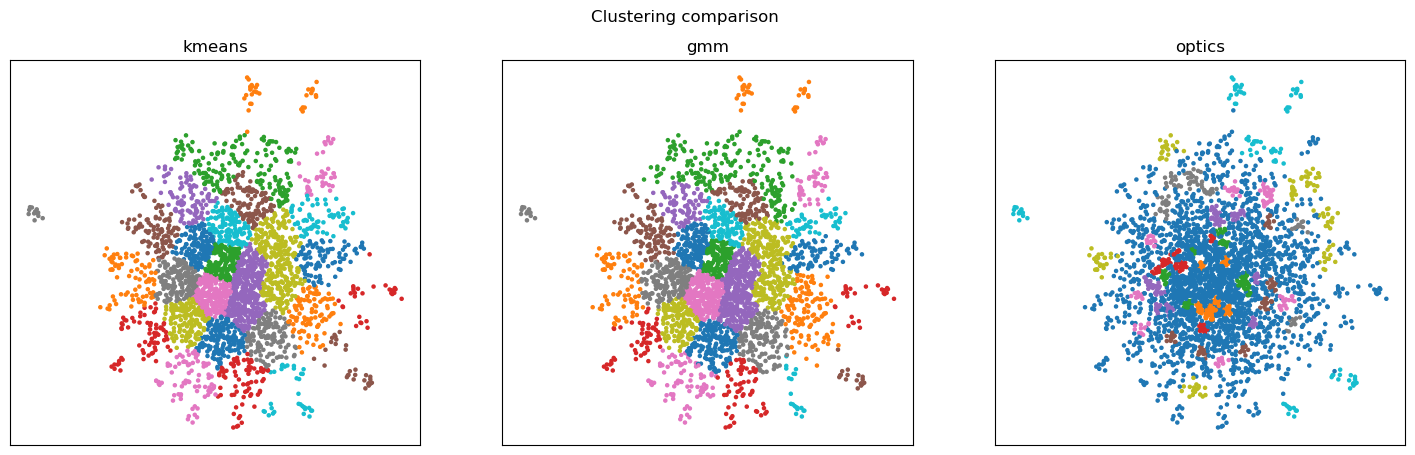

In [84]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, method in enumerate(methods):
    
    if method in ["kmeans", "gmm"]:
        labels = run_clustering(X_umap, method=method, n_clusters=30)
    else:
        labels = run_clustering(X_umap, method=method)
    
    ax = axes[i]
    scatter = ax.scatter(X_umap[:, 0], X_umap[:, 1], c=labels, cmap="tab10", s=5)
    
    ax.set_title(method)
    ax.set_xticks([])
    ax.set_yticks([])

plt.suptitle("Clustering comparison")
plt.show()

In [85]:
df_results = pd.DataFrame(results).T
print(df_results)

        silhouette  davies_bouldin  calinski_harabasz
kmeans    0.322079        0.822517        1887.273664
gmm       0.311421        0.834217        1774.932289
optics    0.624932        0.460607        3335.598766
